# TEXT CLASSIFICATION AND SENTIMENT ANALYSIS

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [3]:
df = pd.read_csv("amazonreviews.tsv",sep="\t")
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [4]:
df.shape

(10000, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [6]:
#Missing values
df.isnull().sum()

label     0
review    0
dtype: int64

In [7]:
#Dupliactes Check
df.duplicated().sum()

np.int64(0)

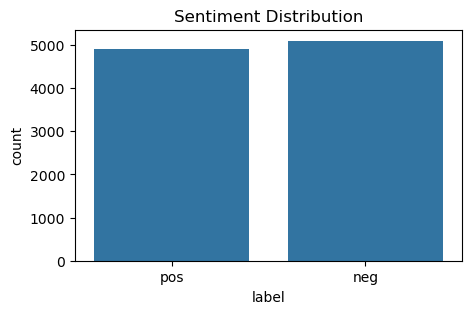

In [8]:
#Analysing Sentiment Distribution
plt.figure(figsize=(5,3))
sns.countplot(
    x='label',
    data=df
)

plt.title("Sentiment Distribution")

plt.show()

## Text Cleaning

In [9]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [10]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PORUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\PORUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [11]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [12]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words]

    return " ".join(words)

In [13]:
df['clean_review'] = df['review'].apply(clean_text)

In [14]:
#Encoding Labels
df['label'] = df['label'].map({'neg':0,
                                'pos':1
                                        })
df.head()

,label,review,clean_review
0,1,Stuning even for the non-gamer: This sound tra...,stuning even non gamer sound track beautiful p...
1,1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything reading lot revi...
2,1,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hand in...
3,1,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,1,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing played game kn...


## WordCloud-Positive Reviews

In [15]:
from wordcloud import WordCloud

In [16]:
positive_text = " ".join(
    df[df['label']==1]['clean_review']
)
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)


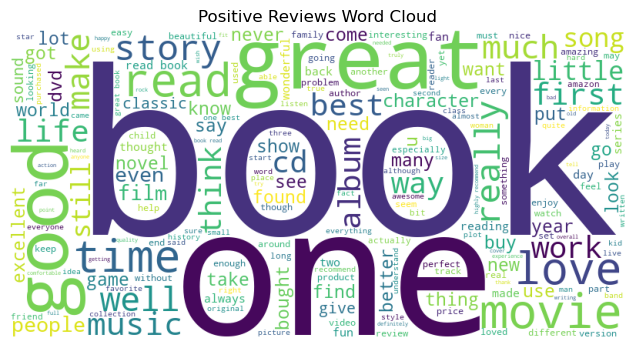

In [17]:

plt.figure(figsize=(8,4))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Positive Reviews Word Cloud")
plt.show()

## Word Cloud – Negative Reviews

In [18]:
negative_text = " ".join(
    df[df['label']==0]['clean_review']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='black'
).generate(negative_text)


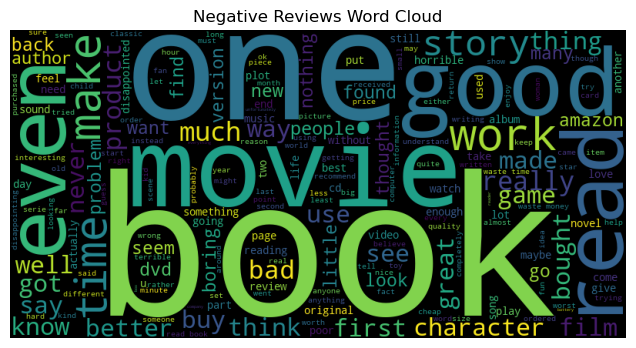

In [19]:
plt.figure(figsize=(8,4))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Negative Reviews Word Cloud")
plt.show()

## Most Common Positive Words

In [20]:
from collections import Counter

In [21]:
positive_words = " ".join(df[df['label']==1]['clean_review']).split()
Counter(positive_words).most_common(20)

[('book', 3933),
 ('great', 2137),
 ('one', 1997),
 ('good', 1671),
 ('read', 1628),
 ('like', 1342),
 ('movie', 1330),
 ('time', 1189),
 ('love', 1045),
 ('would', 956),
 ('get', 948),
 ('well', 947),
 ('story', 875),
 ('really', 832),
 ('best', 813),
 ('first', 724),
 ('make', 711),
 ('year', 703),
 ('work', 701),
 ('much', 664)]

## Most Common Negative Words

In [22]:
negative_words = " ".join(df[df['label']==0]['clean_review']).split()
Counter(negative_words).most_common(20)

[('book', 3760),
 ('one', 2193),
 ('movie', 1784),
 ('like', 1592),
 ('would', 1465),
 ('time', 1321),
 ('get', 1299),
 ('read', 1275),
 ('good', 1163),
 ('even', 910),
 ('buy', 842),
 ('really', 783),
 ('much', 782),
 ('work', 781),
 ('story', 781),
 ('make', 776),
 ('money', 767),
 ('bad', 764),
 ('first', 760),
 ('product', 707)]

# TF-IDF Feature Extraction

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [24]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(
    df['clean_review']
)

X.shape

(10000, 5000)

In [25]:
# Train-Test-Split
from sklearn.model_selection import train_test_split

y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

print(X_train.shape)
print(X_test.shape)

(8000, 5000)
(2000, 5000)


In [26]:
# Logistic Reression Model
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [27]:
#Prediction
y_pred_lr = lr_model.predict(X_test)

In [28]:
#Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision :", precision_score(y_test, y_pred_lr))
print("Recall :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.8505
Precision : 0.8465553235908142
Recall : 0.842159916926272
F1 Score : 0.8443519000520562


In [29]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1037
           1       0.85      0.84      0.84       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



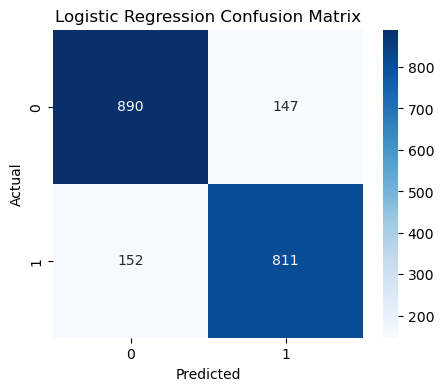

In [30]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Support Vector Machine (SVM)

In [31]:
#Train SVM Model
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit( X_train,y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [32]:
#Prediction
y_pred_svm = svm_model.predict(X_test)

In [33]:
#Evaluation Metrics

svm_accuracy = accuracy_score(y_test,y_pred_svm)
svm_precision = precision_score(y_test,y_pred_svm)
svm_recall = recall_score(y_test,y_pred_svm)
svm_f1 = f1_score(y_test,y_pred_svm)

print("Accuracy :", svm_accuracy)
print("Precision :", svm_precision)
print("Recall :", svm_recall)
print("F1 Score :", svm_f1)

Accuracy : 0.845
Precision : 0.8376421923474664
Recall : 0.8411214953271028
F1 Score : 0.8393782383419689


In [34]:
#Classification Report 
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred_svm))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1037
           1       0.84      0.84      0.84       963

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.85      0.84      0.85      2000



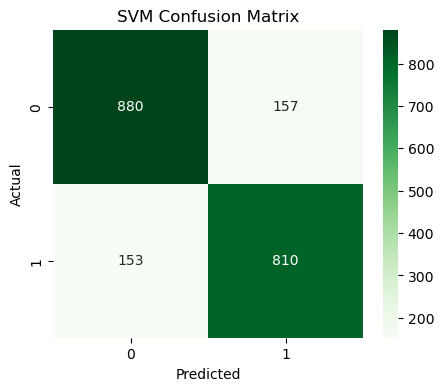

In [35]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred_svm)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Greens')

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Cross Validation

In [36]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(svm_model,X,y,cv=5,scoring='accuracy')

print("Cross Validation Scores")
print(cv_scores)
print("\nMean Accuracy")
print(cv_scores.mean())

Cross Validation Scores
[0.8505 0.8075 0.8095 0.826  0.8395]

Mean Accuracy
0.8266


In [37]:
#Model Comparison
lr_accuracy = accuracy_score(y_test,y_pred_lr)

lr_f1 = f1_score(y_test,y_pred_lr)

comparison = pd.DataFrame({'Model':['Logistic Regression', 'SVM'],
                            'Accuracy':[lr_accuracy,svm_accuracy ],
                            'F1 Score':[ lr_f1,svm_f1]
                          })

comparison

,Model,Accuracy,F1 Score
0,Logistic Regression,0.8505,0.844352
1,SVM,0.8450,0.839378


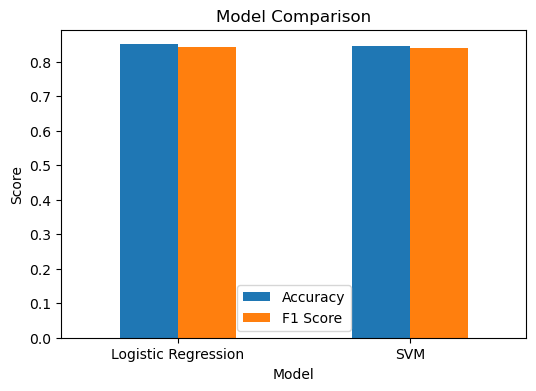

In [38]:
#Comparison Graph
comparison.set_index('Model').plot(kind='bar',figsize=(6,4))

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

## Model Comparison:
- Both Logistic Regression and SVM successfully classified customer reviews into positive and negative sentiments using TF-IDF features extracted from review text.
- Logistic Regression achieved an accuracy of 85.05% and an F1-score of 84.44%, slightly outperforming SVM, which achieved 84.50% accuracy and 83.94% F1-score.
- Based on the evaluation metrics, Logistic Regression performed marginally better and can be selected as the preferred model for sentiment classification in this dataset.

## Model Performance:
- Logistic Regression showed slightly better predictive performance than SVM, indicating that it captured sentiment patterns more effectively in the review dataset.
- The use of TF-IDF feature extraction helped both models convert textual reviews into meaningful numerical representations for classification.
- Cross-validation results confirmed that the models generalized well to unseen reviews and produced consistent sentiment predictions.

## Conclusion
Customer reviews were successfully preprocessed using NLP techniques such as lowercasing, stopword removal, and text cleaning.
TF-IDF feature extraction combined with machine learning algorithms effectively classified reviews as positive or negative.
Logistic Regression emerged as the best-performing model with 85.05% accuracy, making it suitable for automated customer sentiment monitoring and product feedback analysis.